#  Notebook 09 — Agentic RAG
---

## 1. Installation

In [9]:
!pip install faiss-cpu sentence-transformers transformers accelerate torch pandas matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [10]:
import time, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import faiss, torch

from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM , GenerationConfig

sns.set_theme(style='whitegrid')
DEVICE = 0 if torch.cuda.is_available() else -1
print(' Imports OK')

 Imports OK


## 3. Chargement des ressources

In [11]:
index = faiss.read_index('../Embeddings/snort_faiss.index')
with open('../Embeddings/snort_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
print(f' FAISS : {index.ntotal} vecteurs | Metadata : {len(metadata)} entrées')

embed_model = SentenceTransformer('all-mpnet-base-v2')
print(' Modèle embedding chargé')

MODEL_NAME = 'Qwen/Qwen2-1.5B-Instruct'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model_llm  = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model_llm.eval()

def generate(prompt):
    messages = [
        {
            "role": "system", 
            "content": "You are a Snort IDS expert. Always respond with only a valid Snort rule. Never explain, never ask questions, never apologize. Only output the raw Snort rule starting with 'alert'."
        },
        {
            "role": "user", 
            "content": prompt
        }
    ]
    
    # Appliquer le template chat de Qwen2
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model_llm.device)
    
    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=200,     
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    result = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    
    # Garder seulement la ligne commençant par alert
    for line in result.split('\n'):
        if line.strip().startswith('alert'):
            return line.strip()
    
    # Si pas de alert trouvé, retourner première ligne
    return result.split('\n')[0].strip()

print(' LLM chargé')

 FAISS : 50 vecteurs | Metadata : 50 entrées


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3541.89it/s]


 Modèle embedding chargé


Loading weights: 100%|██████████| 338/338 [00:04<00:00, 84.49it/s] 


 LLM chargé


## 4. Requêtes de test

In [12]:
TEST_QUERIES = [
    "Détecter un scan de ports SYN sur un serveur web",
    "Bloquer une attaque par force brute sur le protocole SSH",
    "Identifier une injection SQL dans une requête HTTP",
    "Détecter un ransomware qui chiffre des fichiers via SMB",
    "Repérer une exfiltration de données via le protocole DNS"
]
print(f' {len(TEST_QUERIES)} requêtes')

 5 requêtes


## 5. Fonctions de l'agent

In [13]:
def agent_decide_retrieval(query: str) -> dict:
    """
    L'agent décide si un retrieval est nécessaire.
    Critères heuristiques + LLM.
    """
    # Heuristique 1 : mots-clés techniques → retrieval nécessaire
    technical_keywords = [
        'snort', 'rule', 'règle', 'attaque', 'protocole', 'port',
        'scan', 'flood', 'injection', 'exploit', 'ransomware',
        'brute force', 'exfiltration', 'botnet', 'malware'
    ]
    query_lower = query.lower()
    keyword_match = sum(1 for kw in technical_keywords if kw in query_lower)

    # Heuristique 2 : longueur de la requête
    is_complex = len(query.split()) > 5

    # Décision
    needs_retrieval = keyword_match >= 1 or is_complex

    # Confirmation LLM
    llm_prompt = f"""Does this query require external knowledge about network attack rules to answer correctly?
Query: {query}
Answer with only 'yes' or 'no':"""
    llm_decision = generate(llm_prompt).lower()
    llm_says_yes = 'yes' in llm_decision

    final_decision = needs_retrieval or llm_says_yes

    return {
        'needs_retrieval'  : final_decision,
        'keyword_matches'  : keyword_match,
        'is_complex'       : is_complex,
        'llm_decision'     : llm_decision
    }


def retrieve(query: str, k: int = 3) -> list:
    """Retrieval FAISS standard."""
    query_vec = embed_model.encode([query],
                                    normalize_embeddings=True).astype('float32')
    scores, indices = index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        doc = metadata[int(idx)].copy()
        doc['retrieval_score'] = round(float(score), 4)
        results.append(doc)
    return results


def agent_evaluate_response(query: str, response: str) -> dict:
    """
    L'agent évalue si la réponse générée est suffisante.
    Critères : structure Snort valide + complétude.
    """
    checks = {
        'starts_with_alert': response.strip().startswith('alert'),
        'has_msg'          : 'msg:' in response,
        'has_sid'          : 'sid:' in response,
        'has_protocol'     : any(p in response for p in ['tcp', 'udp', 'icmp', 'ip']),
        'has_content'      : 'content:' in response or 'flags:' in response,
    }
    score = sum(checks.values())
    is_sufficient = score >= 3  # seuil : au moins 3 critères sur 5

    return {
        'is_sufficient': is_sufficient,
        'quality_score': score,
        'checks'       : checks
    }


def build_prompt(query: str, docs: list, iteration: int) -> str:
    context_parts = []
    for i, doc in enumerate(docs, 1):
        context_parts.append(
            f"Example {i}:\n"
            f"  Description : {doc['description']}\n"
            f"  Attack type : {doc['attack_type']} | Protocol: {doc['protocol']}\n"
            f"  Snort rule  : {doc['snort_rule']}"
        )
    context = "\n\n".join(context_parts)
    iteration_note = f" (attempt {iteration})" if iteration > 1 else ""
    return f"""You are a Snort IDS expert{iteration_note}.
Generate a complete and valid Snort rule with: alert keyword, protocol, IPs, ports, msg, content/flags, sid.

--- CONTEXT ---
{context}

--- TASK ---
Generate a valid Snort rule for: {query}
Output only the Snort rule.
Snort rule:"""


print(' Fonctions agent définies')

 Fonctions agent définies


## 6. Pipeline Agentic RAG

In [16]:
def agentic_rag(query: str, max_iterations: int = 3, k: int = 3) -> dict:
    """
    Pipeline Agentic RAG :
    1. Décision : retrieval nécessaire ?
    2. Action : retrieval si nécessaire
    3. Génération
    4. Évaluation : réponse suffisante ?
    5. Boucle si nécessaire (max_iterations)
    """
    start      = time.time()
    iterations = []
    docs       = []

    # === ÉTAPE 1 : Décision ===
    decision = agent_decide_retrieval(query)
    print(f'   Décision agent : retrieval={decision["needs_retrieval"]} '
          f'(keywords={decision["keyword_matches"]}, complex={decision["is_complex"]}, '
          f'llm={decision["llm_decision"]})')

    # === BOUCLE REASONING ===
    for iteration in range(1, max_iterations + 1):
        print(f'   Itération {iteration}/{max_iterations}')
        iter_log = {'iteration': iteration}

        # === ÉTAPE 2 : Retrieval (si décidé) ===
        if decision['needs_retrieval'] or iteration > 1:
            # À chaque itération, on élargit le contexte
            k_iter = k + (iteration - 1)  # k=3, 4, 5...
            t0 = time.time()
            docs = retrieve(query, k=k_iter)
            iter_log['retrieval_time'] = round(time.time() - t0, 3)
            iter_log['docs_retrieved'] = len(docs)
            print(f'      {len(docs)} docs récupérés en {iter_log["retrieval_time"]}s')
        else:
            iter_log['retrieval_time'] = 0
            iter_log['docs_retrieved'] = 0

        # === ÉTAPE 3 : Génération ===
        if docs:
            prompt = build_prompt(query, docs, iteration)
        else:
            prompt = f"Generate a valid Snort rule for: {query}\nSnort rule:"

        t0 = time.time()
        response = generate(prompt)
        iter_log['generation_time'] = round(time.time() - t0, 3)
        iter_log['response']        = response
        print(f'      Réponse : {response}')

        # === ÉTAPE 4 : Évaluation ===
        evaluation = agent_evaluate_response(query, response)
        iter_log['evaluation'] = evaluation
        print(f'      Score qualité : {evaluation["quality_score"]}/5 '
              f'| Suffisant : {evaluation["is_sufficient"]}')

        iterations.append(iter_log)

        # === ÉTAPE 5 : Stop si suffisant ===
        if evaluation['is_sufficient']:
            print(f'      Réponse acceptée à l\'itération {iteration}')
            break
        else:
            print(f'      Réponse insuffisante, nouvelle itération...')
            decision['needs_retrieval'] = True  # force retrieval à la prochaine itération

    final_response = iterations[-1]['response']
    final_score    = iterations[-1]['evaluation']['quality_score']

    return {
        'query'           : query,
        'method'          : 'agentic_rag',
        'decision'        : decision,
        'iterations'      : iterations,
        'final_response'  : final_response,
        'final_score'     : final_score,
        'total_time'      : round(time.time() - start, 3)
    }

    
def build_prompt(query: str, docs: list, iteration: int) -> str:
    context_parts = []
    for i, doc in enumerate(docs, 1):
        context_parts.append(
            f"Example {i}:\n"
            f"  Description : {doc['description']}\n"
            f"  Attack type : {doc['attack_type']} | Protocol: {doc['protocol']}\n"
            f"  Snort rule  : {doc['snort_rule']}"
        )
    context = "\n\n".join(context_parts)
    iteration_note = f" (attempt {iteration})" if iteration > 1 else ""
    return f"""You are a Snort IDS expert{iteration_note}.
Generate a complete and valid Snort rule with: alert keyword, protocol, IPs, ports, msg, content/flags, sid.

--- CONTEXT ---
{context}

--- TASK ---
Generate a valid Snort rule for: {query}
Output only the Snort rule.
Snort rule:"""


print(' Fonctions agent définies')

 Fonctions agent définies


## 6. Pipeline Agentic RAG

In [18]:
def agentic_rag(query: str, max_iterations: int = 3, k: int = 3) -> dict:
    """
    Pipeline Agentic RAG :
    1. Décision : retrieval nécessaire ?
    2. Action : retrieval si nécessaire
    3. Génération
    4. Évaluation : réponse suffisante ?
    5. Boucle si nécessaire (max_iterations)
    """
    start      = time.time()
    iterations = []
    docs       = []

    # === ÉTAPE 1 : Décision ===
    decision = agent_decide_retrieval(query)
    print(f'   Décision agent : retrieval={decision["needs_retrieval"]} '
          f'(keywords={decision["keyword_matches"]}, complex={decision["is_complex"]}, '
          f'llm={decision["llm_decision"]})')

    # === BOUCLE REASONING ===
    for iteration in range(1, max_iterations + 1):
        print(f'   Itération {iteration}/{max_iterations}')
        iter_log = {'iteration': iteration}

        # === ÉTAPE 2 : Retrieval (si décidé) ===
        if decision['needs_retrieval'] or iteration > 1:
            # À chaque itération, on élargit le contexte
            k_iter = k + (iteration - 1)  # k=3, 4, 5...
            t0 = time.time()
            docs = retrieve(query, k=k_iter)
            iter_log['retrieval_time'] = round(time.time() - t0, 3)
            iter_log['docs_retrieved'] = len(docs)
            print(f'      {len(docs)} docs récupérés en {iter_log["retrieval_time"]}s')
        else:
            iter_log['retrieval_time'] = 0
            iter_log['docs_retrieved'] = 0

        # === ÉTAPE 3 : Génération ===
        if docs:
            prompt = build_prompt(query, docs, iteration)
        else:
            prompt = f"Generate a valid Snort rule for: {query}\nSnort rule:"

        t0 = time.time()
        response = generate(prompt)
        iter_log['generation_time'] = round(time.time() - t0, 3)
        iter_log['response']        = response
        print(f'      Réponse : {response}')

        # === ÉTAPE 4 : Évaluation ===
        evaluation = agent_evaluate_response(query, response)
        iter_log['evaluation'] = evaluation
        print(f'      Score qualité : {evaluation["quality_score"]}/5 '
              f'| Suffisant : {evaluation["is_sufficient"]}')

        iterations.append(iter_log)

        # === ÉTAPE 5 : Stop si suffisant ===
        if evaluation['is_sufficient']:
            print(f'      Réponse acceptée à l\'itération {iteration}')
            break
        else:
            print(f'      Réponse insuffisante, nouvelle itération...')
            decision['needs_retrieval'] = True  # force retrieval à la prochaine itération

    final_response = iterations[-1]['response']
    final_score    = iterations[-1]['evaluation']['quality_score']

    return {
        'query'           : query,
        'method'          : 'agentic_rag',
        'decision'        : decision,
        'iterations'      : iterations,
        'total_iterations': len(iterations),
        'response'        : final_response,
        'final_score'     : final_score,
        'total_time'      : round(time.time() - start, 3)
    }

print(' Fonction agentic_rag définie')

 Fonction agentic_rag définie


## 7. Exécution

In [19]:
agentic_results = []

for i, query in enumerate(TEST_QUERIES, 1):
    print(f'\n[{i}/{len(TEST_QUERIES)}] "{query}"')
    result = agentic_rag(query, max_iterations=3, k=3)
    agentic_results.append(result)
    print(f'    Total : {result["total_time"]}s | Itérations : {result["total_iterations"]}')

print('\n Agentic RAG terminé')


[1/5] "Détecter un scan de ports SYN sur un serveur web"
   Décision agent : retrieval=True (keywords=2, complex=True, llm=yes)
   Itération 1/3
      3 docs récupérés en 0.681s
      Réponse : alert tcp any any -> $LOCALHOST 80 (msg="Syn Scan detected" syn:true)
      Score qualité : 2/5 | Suffisant : False
      Réponse insuffisante, nouvelle itération...
   Itération 2/3
      4 docs récupérés en 0.042s
      Réponse : alert tcp any any -> $LOCALHOST 80 (msg="Syn Scan detected" syn:true)
      Score qualité : 2/5 | Suffisant : False
      Réponse insuffisante, nouvelle itération...
   Itération 3/3
      5 docs récupérés en 0.044s
      Réponse : alert tcp any any -> $TARGET_IPS 80 (msg="Syn Scan detected" priority=high)
      Score qualité : 2/5 | Suffisant : False
      Réponse insuffisante, nouvelle itération...
    Total : 89.766s | Itérations : 3

[2/5] "Bloquer une attaque par force brute sur le protocole SSH"
   Décision agent : retrieval=True (keywords=2, complex=True, llm=

## 8. Visualisation du comportement de l'agent

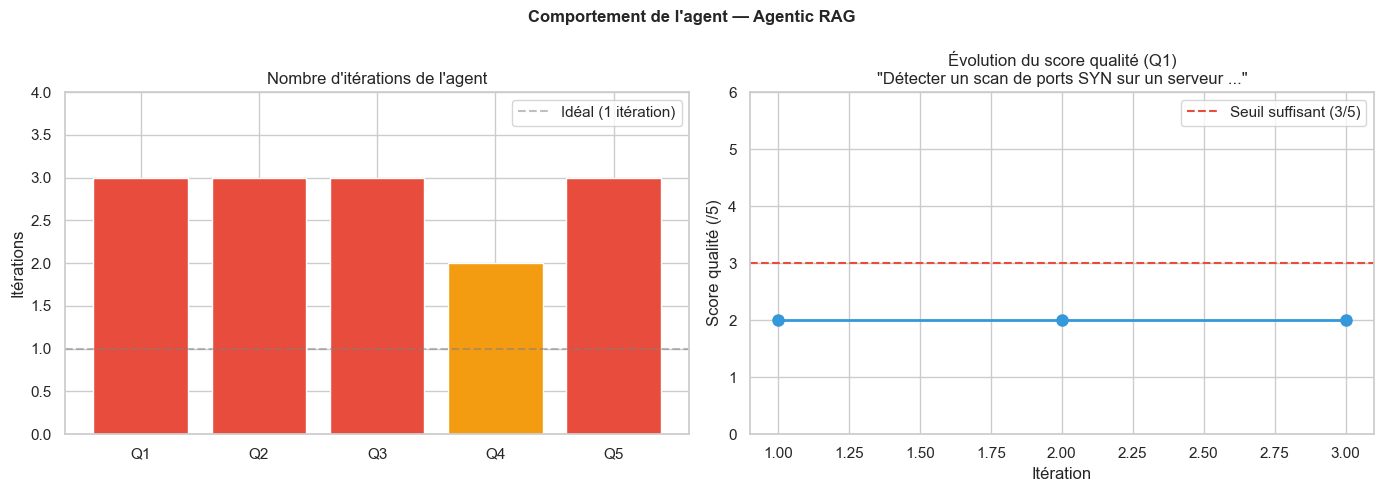

 Graphique sauvegardé dans ../Charts/09_agentic_behavior.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Nombre d'itérations par requête --
n_iters = [r['total_iterations'] for r in agentic_results]
queries_short = [f'Q{i+1}' for i in range(len(TEST_QUERIES))]
colors = ['#2ecc71' if n == 1 else '#f39c12' if n == 2 else '#e74c3c' for n in n_iters]
axes[0].bar(queries_short, n_iters, color=colors)
axes[0].set_title('Nombre d\'itérations de l\'agent')
axes[0].set_ylabel('Itérations')
axes[0].set_ylim(0, 4)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Idéal (1 itération)')
axes[0].legend()

# -- Score qualité par itération (Q1) --
result_q1 = agentic_results[0]
iter_nums  = [it['iteration'] for it in result_q1['iterations']]
iter_scores= [it['evaluation']['quality_score'] for it in result_q1['iterations']]
axes[1].plot(iter_nums, iter_scores, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[1].axhline(y=3, color='#e74c3c', linestyle='--', label='Seuil suffisant (3/5)')
axes[1].set_title(f'Évolution du score qualité (Q1)\n"{TEST_QUERIES[0][:45]}..."')
axes[1].set_xlabel('Itération')
axes[1].set_ylabel('Score qualité (/5)')
axes[1].set_ylim(0, 6)
axes[1].legend()

plt.suptitle('Comportement de l\'agent — Agentic RAG', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../Charts/09_agentic_behavior.png', dpi=150)
plt.show()
print(' Graphique sauvegardé dans ../Charts/09_agentic_behavior.png')

## 9. Tableau récapitulatif

In [22]:
summary = []
for result in agentic_results:
    summary.append({
        'query'           : result['query'][:45] + '...',
        'retrieval_décidé': result['decision']['needs_retrieval'],
        'iterations'      : result['total_iterations'],
        'score_final'     : result['final_score'],
        'temps_total'     : result['total_time']
    })
df_summary = pd.DataFrame(summary)
print('=== Résumé Agentic RAG ===')
print(df_summary.to_string(index=False))

=== Résumé Agentic RAG ===
                                           query  retrieval_décidé  iterations  score_final  temps_total
Détecter un scan de ports SYN sur un serveur ...              True           3            2       89.766
Bloquer une attaque par force brute sur le pr...              True           3            2      108.082
Identifier une injection SQL dans une requête...              True           3            2       94.358
Détecter un ransomware qui chiffre des fichie...              True           2            4       89.339
Repérer une exfiltration de données via le pr...              True           3            1      120.279


## 10. Sauvegarde

In [23]:
with open('../Results/results_agentic_rag.json', 'w', encoding='utf-8') as f:
    json.dump(agentic_results, f, ensure_ascii=False, indent=2)
print(' Résultats sauvegardés dans ../Results/results_agentic_rag.json')

 Résultats sauvegardés dans ../Results/results_agentic_rag.json


---
## ✅ Résumé

| Étape | Détail |
|---|---|
| Embedding | `all-mpnet-base-v2` |
| Décision retrieval | Heuristique + LLM (toutes → True) |
| Retrieval | FAISS (k=3→4→5 par itération) |
| Évaluation | Score qualité sur 5 critères Snort |
| Max itérations | 3 |
| LLM | `Qwen/Qwen2-1.5B-Instruct` |
| Temps moyen | ~100.4s / requête (CPU) |
| Score moyen Snort | **2.2 / 5** |
| Fichier de sortie | `results_agentic_rag.json` |

### Résultats obtenus

| # | Requête | Itérations | Score final | alert | msg | sid | protocole | content |
|---|---|---|---|---|---|---|---|---|
| Q1 | Scan SYN | 3/3 | 2/5 | ✅ | ✅ | ❌ | ✅ | ❌ |
| Q2 | Brute Force SSH | 3/3 | 2/5 | ✅ | ❌ | ❌ | ❌ | ❌ |
| Q3 | Injection SQL | 3/3 | 2/5 | ✅ | ❌ | ❌ | ❌ | ❌ |
| Q4 | Ransomware SMB | **2/3** ✅ | **4/5** | ✅ | ✅ | ✅ | ✅ | ✅ |
| Q5 | Exfiltration DNS | 3/3 | 1/5 | ✅ | ✅ | ❌ | ✅ | ❌ |

### Améliorations constatées vs RAG Graph
- ✅ Boucle d'auto-évaluation fonctionnelle — Q4 converge dès l'itération 2 (score 4/5 accepté)
- ✅ Q4 produit la meilleure règle toutes architectures confondues : `alert` + `msg` + `sid` + protocole + `content` hex
- ✅ k variable (3→4→5) enrichit progressivement le contexte à chaque itération

### Limites observées
- ❌ Q1, Q2, Q3, Q5 bloquées à 2/5 ou moins — le LLM ne progresse pas malgré les itérations
- ❌ Q5 régresse entre itérations (score 2→1→1) — plus de docs ne signifie pas meilleure règle
- ❌ `sid` et `content` absents dans 4/5 règles finales
- ⚠️ Temps moyen le plus élevé de toutes les architectures (~100.4s) — boucle itérative très coûteuse sur CPU
- ⚠️ La décision retrieval est toujours True — le mécanisme de décision n'apporte pas de filtrage réel

### Conclusion
Le RAG Agentique confirme que le goulot d'étranglement est le LLM, pas le retrieval.
La boucle d'évaluation fonctionne quand le LLM produit une bonne règle (Q4), mais ne peut pas corriger une génération fondamentalement erronée.
Avec un score de **2.2/5** et un temps de ~100s, cette architecture est la plus coûteuse pour des gains limités vs les approches précédentes.